Configure HF Token

In [ ]:
import os
import sys

if "google.colab" in sys.modules and not os.environ.get("VERTEX_PRODUCT"):
    # Use secret if running in Google Colab
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
else:
    # Store Hugging Face data under `/content` if running in Colab Enterprise
    if os.environ.get("VERTEX_PRODUCT") == "COLAB_ENTERPRISE":
        os.environ["HF_HOME"] = "/content/hf"
    # Authenticate with Hugging Face
    from huggingface_hub import get_token
    if get_token() is None:
        from huggingface_hub import notebook_login
        notebook_login()

Install Dependencies

In [ ]:
! pip install --upgrade --quiet bitsandbytes datasets evaluate peft tensorboard transformers trl torchao

import mendeley dataset

In [ ]:
import os
import pandas as pd
from pathlib import Path
from PIL import Image
from datasets import Dataset

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Dissertation"
Mendeley_path = PROJECT_DIR + "/datasets/Bone_fracture_dataset/Original"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Build Mendeley dataset

In [ ]:
import os
import pandas as pd
from datasets import Dataset

Mendeley_path = "/content/drive/MyDrive/Dissertation/datasets/Bone_fracture_dataset/Original"

FRACTURE_CLASSES = [
    "A: simple fracture",
    "B: comminuted fracture",
]

FOLDER_TO_CLASS = {
    "Simple Bone Fracture": "A: simple fracture",
    "Comminuted Bone Fracture": "B: comminuted fracture",
}

options = "\n".join(FRACTURE_CLASSES)
PROMPT_A = f"What type of bone fracture is shown in this X-ray?\n{options}"

def build_mendeley_examples(root=Mendeley_path):
    examples = []
    for folder_name, class_label in FOLDER_TO_CLASS.items():
        folder_path = os.path.join(root, folder_name)
        for fname in os.listdir(folder_path):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            examples.append({
                "image_path": os.path.join(folder_path, fname),
                "label": class_label,
            })
    return examples

mendeley_examples = build_mendeley_examples()
mendeley_df = pd.DataFrame(mendeley_examples)
print(mendeley_df["label"].value_counts())

label
A: simple fracture        1211
B: comminuted fracture    1173
Name: count, dtype: int64


Split the dataset

In [ ]:
from datasets import Dataset, Features, ClassLabel, Value

# Define the features with 'label' as ClassLabel
features = Features({
    "image_path": Value("string"),
    "label": ClassLabel(names=FRACTURE_CLASSES)
})

mendeley_ds = Dataset.from_list(mendeley_examples, features=features)
split1 = mendeley_ds.train_test_split(test_size=0.2, stratify_by_column="label", seed=42)
train_ds_a = split1["train"]
temp_ds_a = split1["test"]

split2 = temp_ds_a.train_test_split(test_size=0.5, stratify_by_column="label", seed=42)
val_ds_a = split2["train"]
test_ds_a = split2["test"]

print("Train:", train_ds_a.num_rows, "Val:", val_ds_a.num_rows, "Test:", test_ds_a.num_rows)

Train: 1907 Val: 238 Test: 239


Add chat format message

In [ ]:
def format_data(example):
    example["messages"] = [
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": PROMPT_A}]},
        {"role": "assistant", "content": [{"type": "text", "text": FRACTURE_CLASSES[example["label"]]}]},
    ]
    return example

train_ds_a = train_ds_a.map(format_data)
val_ds_a = val_ds_a.map(format_data)
test_ds_a = test_ds_a.map(format_data)

print(train_ds_a[0])

Map:   0%|          | 0/1907 [00:00<?, ? examples/s]

Map:   0%|          | 0/238 [00:00<?, ? examples/s]

Map:   0%|          | 0/239 [00:00<?, ? examples/s]

{'image_path': '/content/drive/MyDrive/Dissertation/datasets/Bone_fracture_dataset/Original/Simple Bone Fracture/471_Simple Bone Fracture.jpg', 'label': 0, 'messages': [{'role': 'user', 'content': [{'type': 'image'}, {'type': 'text', 'text': 'What type of bone fracture is shown in this X-ray?\nA: simple fracture\nB: comminuted fracture'}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': 'A: simple fracture'}]}]}


Save splits

In [ ]:
save_base_a = "/content/drive/MyDrive/Dissertation/datasets/mendeley_only_splits"
train_ds_a.save_to_disk(f"{save_base_a}/train_ds")
val_ds_a.save_to_disk(f"{save_base_a}/val_ds")
test_ds_a.save_to_disk(f"{save_base_a}/test_ds")
print("Saved Model A splits")

Saving the dataset (0/1 shards):   0%|          | 0/1907 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/238 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/239 [00:00<?, ? examples/s]

Saved Model A splits


Sanity Check

0 -> A: simple fracture


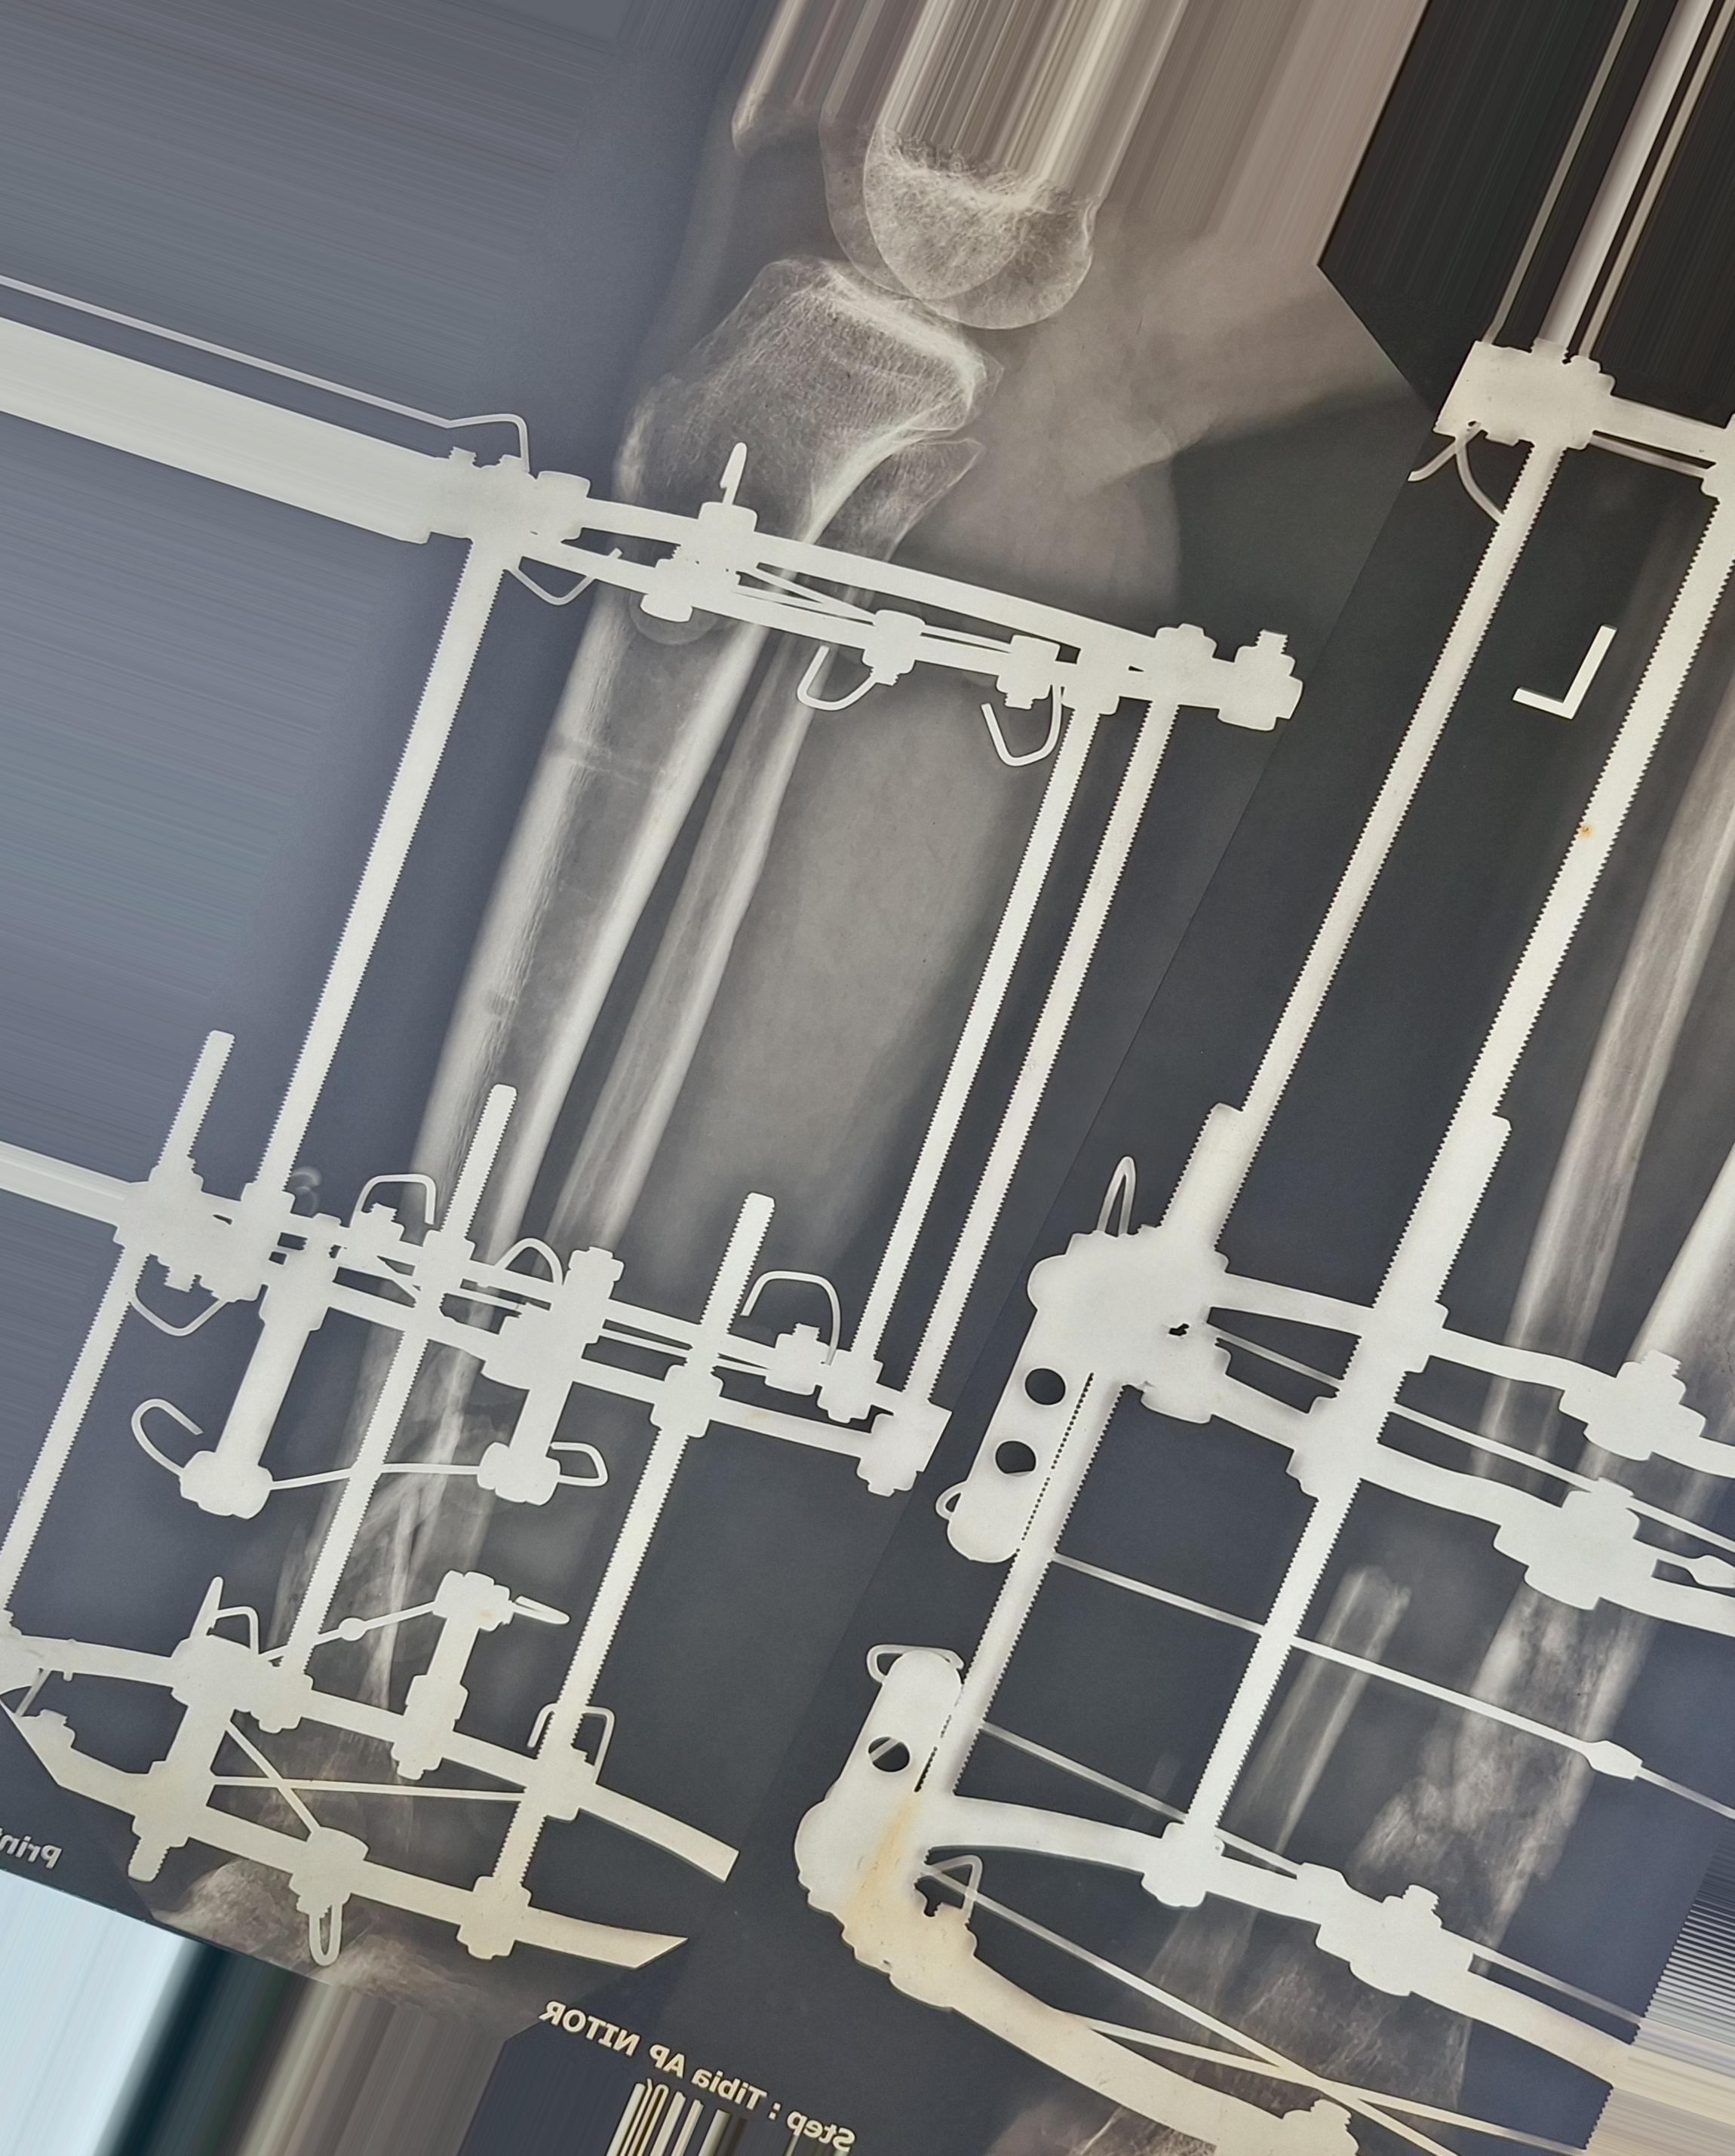

In [ ]:
print(train_ds_a[4]["label"], "->", FRACTURE_CLASSES[train_ds_a[3]["label"]])
Image.open(train_ds_a[4]["image_path"]).convert("RGB")

Load Model

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

model_id = "google/medgemma-4b-it"

if torch.cuda.get_device_capability()[0] < 8:
    raise ValueError("GPU does not support bfloat16, please use a GPU that supports bfloat16.")

model_kwargs = dict(
    attn_implementation="sdpa",
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

model = AutoModelForImageTextToText.from_pretrained(model_id, **model_kwargs)
processor = AutoProcessor.from_pretrained(model_id)
processor.tokenizer.padding_side = "right"

config.json:   0%|          | 0.00/2.47k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

LoRA config

In [ ]:
from peft import LoraConfig

peft_config = LoraConfig(
    lora_alpha=16,
    lora_dropout=0.05,
    r=16,
    bias="none",
    target_modules="all-linear",
    task_type="CAUSAL_LM",
    modules_to_save=["lm_head", "embed_tokens"],
)

Collate function

In [ ]:
from typing import Any
from PIL import Image

def collate_fn(examples: list[dict[str, Any]]):
    texts = []
    images = []
    for example in examples:
        image = Image.open(example["image_path"]).convert("RGB")
        images.append([image])
        texts.append(processor.apply_chat_template(
            example["messages"], add_generation_prompt=False, tokenize=False
        ).strip())

    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()

    image_token_id = [
        processor.tokenizer.convert_tokens_to_ids(
            processor.tokenizer.special_tokens_map["boi_token"]
        )
    ]
    labels[labels == processor.tokenizer.pad_token_id] = -100
    labels[labels == image_token_id] = -100
    labels[labels == 262144] = -100

    batch["labels"] = labels
    return batch

Training config

In [ ]:
from trl import SFTConfig

args_a = SFTConfig(
    output_dir="medgemma-4b-it-sft-lora-mendeley",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="adamw_torch_fused",
    logging_steps=20,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    eval_strategy="steps",
    eval_steps=20,
    learning_rate=2e-4,
    bf16=True,
    max_grad_norm=0.3,
    lr_scheduler_type="linear",
    push_to_hub=False,
    report_to="tensorboard",
    dataset_kwargs={"skip_prepare_dataset": True},
    remove_unused_columns=False,
    label_names=["labels"],
)

Trainer and launch

In [ ]:
from trl import SFTTrainer

trainer_a = SFTTrainer(
    model=model,
    args=args_a,
    train_dataset=train_ds_a,
    eval_dataset=val_ds_a.shuffle(seed=42).select(range(min(200, val_ds_a.num_rows))),
    peft_config=peft_config,
    processing_class=processor,
    data_collator=collate_fn,
)

trainer_a.train()

/usr/local/lib/python3.13/dist-packages/peft/tuners/tuners_utils.py:1377: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
20,1.401946,0.119379,0.075086,95974.000000,0.968029
40,0.065673,0.055659,0.044011,191956.000000,0.965500
60,0.053966,0.054290,0.043484,287972.000000,0.965500
80,0.051514,0.046770,0.050303,383994.000000,0.969649
100,0.048153,0.046318,0.048747,479996.000000,0.969304
120,0.046466,0.051671,0.041756,572069.000000,0.967462
140,0.049003,0.046941,0.046019,668077.000000,0.968195
160,0.045423,0.045516,0.042441,764065.000000,0.970014
180,0.045313,0.042624,0.043397,860061.000000,0.971392
200,0.042703,0.042376,0.040445,956071.000000,0.971957


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
20,1.401946,0.119379,0.075086,95974.000000,0.968029
40,0.065673,0.055659,0.044011,191956.000000,0.965500
60,0.053966,0.054290,0.043484,287972.000000,0.965500
80,0.051514,0.046770,0.050303,383994.000000,0.969649
100,0.048153,0.046318,0.048747,479996.000000,0.969304
120,0.046466,0.051671,0.041756,572069.000000,0.967462
140,0.049003,0.046941,0.046019,668077.000000,0.968195
160,0.045423,0.045516,0.042441,764065.000000,0.970014
180,0.045313,0.042624,0.043397,860061.000000,0.971392
200,0.042703,0.042376,0.040445,956071.000000,0.971957


TrainOutput(global_step=360, training_loss=0.12042795999182596, metrics={'train_runtime': 3637.9636, 'train_samples_per_second': 1.573, 'train_steps_per_second': 0.099, 'total_flos': 4.475701532475888e+16, 'train_loss': 0.12042795999182596, 'epoch': 3.0})

Save the model

In [ ]:
trainer_a.save_model("medgemma-4b-it-sft-lora-mendeley-final")
processor.save_pretrained("medgemma-4b-it-sft-lora-mendeley-final")

!mkdir -p /content/drive/MyDrive/Dissertation/models
!cp -r medgemma-4b-it-sft-lora-mendeley-final /content/drive/MyDrive/Dissertation/models/
print("Saved")

Saved


Check Loss curve

In [ ]:
print(trainer_a.state.log_history[-10:])

[{'eval_loss': 0.04209122806787491, 'eval_runtime': 27.5561, 'eval_samples_per_second': 7.258, 'eval_steps_per_second': 1.814, 'eval_entropy': 0.0387392070889473, 'eval_num_tokens': 1336118.0, 'eval_mean_token_accuracy': 0.9728736627101898, 'epoch': 2.3354297693920336, 'step': 280}, {'loss': 0.03977466821670532, 'grad_norm': 0.27498164772987366, 'learning_rate': 3.388888888888889e-05, 'entropy': 0.0391899511218071, 'num_tokens': 1432136.0, 'mean_token_accuracy': 0.9740318961441516, 'epoch': 2.50314465408805, 'step': 300}, {'eval_loss': 0.04015536233782768, 'eval_runtime': 27.3626, 'eval_samples_per_second': 7.309, 'eval_steps_per_second': 1.827, 'eval_entropy': 0.039178177416324615, 'eval_num_tokens': 1432136.0, 'eval_mean_token_accuracy': 0.9726437771320343, 'epoch': 2.50314465408805, 'step': 300}, {'loss': 0.0381211906671524, 'grad_norm': 0.39106351137161255, 'learning_rate': 2.277777777777778e-05, 'entropy': 0.03901438284665346, 'num_tokens': 1528156.0, 'mean_token_accuracy': 0.9730

Evaluate on the Mendeley test set

In [ ]:
import torch

def generate_response(image_path, prompt, model, processor, max_new_tokens=20):
    image = Image.open(image_path).convert("RGB")
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}]
    text = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = processor(text=text, images=[image], return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return processor.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def postprocess_a(response_text, do_full_match=False):
    if do_full_match:
        try:
            return FRACTURE_CLASSES.index(response_text.strip())
        except ValueError:
            return None
    for i, label in enumerate(FRACTURE_CLASSES):
        if label in response_text:
            return i
    return None

In [ ]:
import pandas as pd

results_a = []
for i, example in enumerate(test_ds_a):
    gen_text = generate_response(example["image_path"], PROMPT_A, model, processor)
    pred = postprocess_a(gen_text)
    results_a.append({
        "ground_truth": example["label"],
        "prediction": pred,
        "generated_text": gen_text,
    })
    if i % 20 == 0:
        print(f"{i}/{len(test_ds_a)} done")

results_a_df = pd.DataFrame(results_a)
results_a_df.to_csv("/content/drive/MyDrive/Dissertation/results/model_a_results.csv", index=False)

0/239 done
20/239 done
40/239 done
60/239 done
80/239 done
100/239 done
120/239 done
140/239 done
160/239 done
180/239 done
200/239 done
220/239 done


Compute Metrics

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

valid_a = results_a_df.dropna(subset=["prediction"])
print(f"Unparseable: {len(results_a_df) - len(valid_a)} / {len(results_a_df)}")
print(f"Accuracy: {accuracy_score(valid_a['ground_truth'], valid_a['prediction']):.3f}")
print(f"F1 (weighted): {f1_score(valid_a['ground_truth'], valid_a['prediction'], average='weighted'):.3f}")
print(confusion_matrix(valid_a['ground_truth'], valid_a['prediction']))

Unparseable: 0 / 239
Accuracy: 0.900
F1 (weighted): 0.899
[[104  17]
 [  7 111]]


Check Base model

Load base model for evaluation

In [ ]:
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch

base_model_id = "google/medgemma-4b-it"

base_model = AutoModelForImageTextToText.from_pretrained(
    base_model_id,
    attn_implementation="sdpa",
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
base_processor = AutoProcessor.from_pretrained(base_model_id)
base_processor.tokenizer.padding_side = "right"

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Run similar evaluation on the base model

In [ ]:
results_base_a = []
for i, example in enumerate(test_ds_a):
    gen_text = generate_response(example["image_path"], PROMPT_A, base_model, base_processor)
    pred = postprocess_a(gen_text)
    results_base_a.append({
        "ground_truth": example["label"],
        "prediction": pred,
        "generated_text": gen_text,
    })
    if i % 20 == 0:
        print(f"{i}/{len(test_ds_a)} done")

results_base_a_df = pd.DataFrame(results_base_a)
results_base_a_df.to_csv("/content/drive/MyDrive/Dissertation/results/model_a_base_results.csv", index=False)

0/239 done
20/239 done
40/239 done
60/239 done
80/239 done
100/239 done
120/239 done
140/239 done
160/239 done
180/239 done
200/239 done
220/239 done


Compute metrics for base model

In [ ]:
valid_base_a = results_base_a_df.dropna(subset=["prediction"])
print(f"Unparseable: {len(results_base_a_df) - len(valid_base_a)} / {len(results_base_a_df)}")
print(f"Accuracy: {accuracy_score(valid_base_a['ground_truth'], valid_base_a['prediction']):.3f}")
print(f"F1 (weighted): {f1_score(valid_base_a['ground_truth'], valid_base_a['prediction'], average='weighted'):.3f}")
print(confusion_matrix(valid_base_a['ground_truth'], valid_base_a['prediction']))

Unparseable: 77 / 239
Accuracy: 0.457
F1 (weighted): 0.436
[[53 29]
 [59 21]]
